In [ ]:
from pathlib import Path
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
import sklearn
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

sklearn.set_config(transform_output="pandas")
pd.set_option('display.max_rows', None)

archivos = [
    {"url": "https://cdn.buenosaires.gob.ar/datosabiertos/datasets/observatorio-higiene-urbana-caba/indice-calidad-limpieza-icl/medicion-icl-por-nivel.xlsx",
     "local_file": Path("medicion_icl_por_nivel.xlsx")},
    {"url": "https://cdn.buenosaires.gob.ar/datosabiertos/datasets/observatorio-higiene-urbana-caba/indice-calidad-limpieza-icl/cumplimiento-por-medicion-y-nivel.xlsx",
     "local_file": Path("cumplimiento_por_medicion_y_nivel.xlsx")}
]

# Descargar los archivos si no existen
for archivo in archivos:
    local_file = archivo["local_file"]
    url = archivo["url"]

    if not local_file.exists():
        r = requests.get(url)
        local_file.write_bytes(r.content)

df=pd.read_excel("cumplimiento_por_medicion_y_nivel.xlsx")

df['Porcentaje_de_cumplimiento']=df['Porcentaje_de_cumplimiento'].replace('S/D',np.nan)
df=df.astype({"Porcentaje_de_cumplimiento": float})
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

df.head()

<ipython-input-48-2956588f5039>:39: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Porcentaje_de_cumplimiento']=df['Porcentaje_de_cumplimiento'].replace('S/D',np.nan)


,Medicion,Periodo,Estratificacion_geografica,Comunas,Criterio,Porcentaje_de_cumplimiento
0,1,Febrero-Marzo_2018,Ciudad,"1, 2,3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15",Mobiliario_de_higiene_urbana,0.81
1,1,Febrero-Marzo_2018,Ciudad,"1, 2,3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15",Disposicion_de_residuos,0.84
2,1,Febrero-Marzo_2018,Ciudad,"1, 2,3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15",Heces_caninas,0.19
3,1,Febrero-Marzo_2018,Ciudad,"1, 2,3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15",Limpieza_de_veredas_y_calles,0.43
4,1,Febrero-Marzo_2018,Ciudad,"1, 2,3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15",Grafitis_pegatinas_y_otros,0.51


Clustering K-means dependiendo del criterio:

In [ ]:
# Defino X (features)
X = df[['Porcentaje_de_cumplimiento']].dropna()

# Aplicar la transformación al conjunto de datos
scaler = StandardScaler()
X['Porcentaje_normalizado'] = scaler.fit_transform(
    X[['Porcentaje_de_cumplimiento']]
)


kmeans = KMeans(n_clusters=4, random_state=42) #Elijo 4 arbitrariamente
X['Cluster'] = kmeans.fit_predict(X[['Porcentaje_normalizado']])

# Analizo los clusters que se formaron
cluster_summary = X.groupby('Cluster').mean()
print("Resumen por cluster:", cluster_summary)

Resumen por cluster:          Porcentaje_de_cumplimiento  Porcentaje_normalizado
Cluster                                                    
0                          0.924651                1.067899
1                          0.252088               -1.495314
2                          0.519518               -0.476108
3                          0.741765                0.370898


<ipython-input-50-0755d22715b9>:34: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


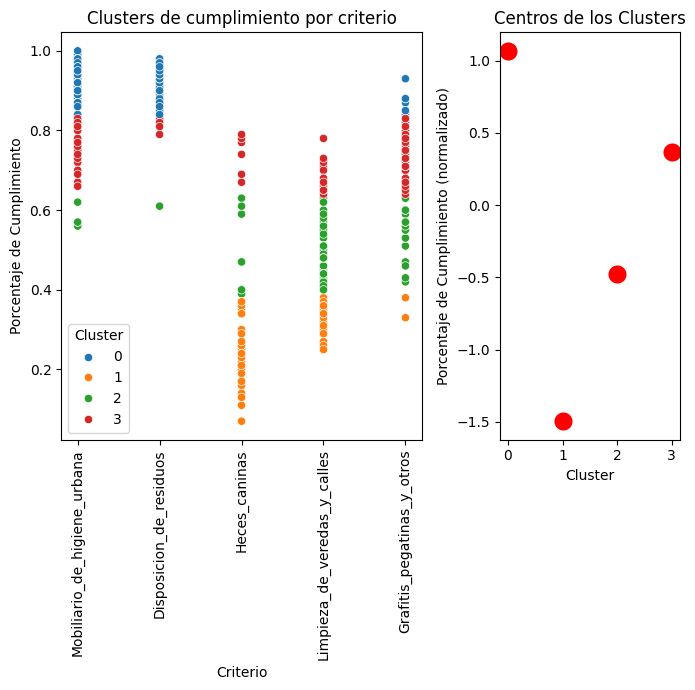

In [ ]:
# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Asociar clusters a los datos originales
try:
  df['Cluster'] = X['Cluster']
except:
  ...
# Obtener los centros de los clusters del modelo
centers = kmeans.cluster_centers_

# Crear una figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(7, 7), gridspec_kw={'width_ratios': [2, 1]})

# Gráfico 1: Puntos por cluster
sns.scatterplot(
    ax=axes[0],
    data=df,
    x='Criterio',
    y='Porcentaje_de_cumplimiento',
    hue='Cluster',
    palette='tab10',
    legend='full'
)
axes[0].set_title('Clusters de cumplimiento por criterio')
axes[0].set_xlabel('Criterio')
axes[0].set_ylabel('Porcentaje de Cumplimiento')
axes[0].tick_params(axis='x', rotation=90)
axes[0].legend(title='Cluster')

# Gráfico 2: Centros del cluster
cluster_indices = np.arange(len(centers))  # Índices para identificar los clusters
sns.scatterplot(
    ax=axes[1],
    x=cluster_indices,
    y=centers[:, 0],  # Centros en el espacio del porcentaje normalizado
    palette='tab10',
    legend=None,
    s=200,  # Tamaño de los puntos
    color='red'
)
axes[1].set_title('Centros de los Clusters')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Porcentaje de Cumplimiento (normalizado)')

# Ajustar diseño
plt.tight_layout()
plt.show()



Veo por el grafico que cada criterio tiene porcentaje de cumplimiento similares siendo el criterio de heces caninas y mobiliario de higiene urbana los que mas se destacan.
Mientras tanto, el criterio de grafitis y movilizacion urbana son los que menos se destacan.

Me fijo si existe relacion entre el porcentaje de cumplimiento y el periodo. Esto lo hago con el dataset de indice de calidad de limpieza

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OneHotEncoder

indice = pd.read_excel("medicion_icl_por_nivel.xlsx")

# Reemplazar "S/D" por NaN y convertir a tipo float
indice['Indice_de_Calidad_de_Limpieza'] = indice['Indice_de_Calidad_de_Limpieza'].replace('S/D', np.nan).astype(float)

# Eliminar filas con valores faltantes
indice = indice.dropna(subset=["Indice_de_Calidad_de_Limpieza"]).reset_index(drop=True)


# Calcular el promedio del índice para cada periodo
indice_promedio = indice.groupby("Periodo", as_index=False)["Indice_de_Calidad_de_Limpieza"].mean()
encoder = ColumnTransformer(
    [("category",OrdinalEncoder(), ["Periodo"]),],  # Codificación para variables categóricas
    remainder="passthrough"
)


# Codificamos 'Periodo'
indice_promedio = encoder.fit_transform(indice_promedio)

# Variables independientes y dependiente
X = indice_promedio[["category__Periodo"]]
y = indice_promedio["remainder__Indice_de_Calidad_de_Limpieza"]

# Crear pipeline con regresión polinomial
model = Pipeline(
    [
        ("polynomial", PolynomialFeatures(degree=2)),  # Genera un polinomio de bajo grado para evitar overfiting
        ("regression", LinearRegression()),  # Ajusta el modelo lineal
    ]
)

# Dividir en train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar modelo
model.fit(X_train, y_train)

# Evaluar modelo
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

# Resultados
print("Train score (R^2):", train_score)
print("Test score (R^2):", test_score)
print("Mean Squared Error (MSE):", mse)

Train score (R^2): 0.1389125805063145
Test score (R^2): -3.58714097040691
Mean Squared Error (MSE): 47.245578568919484


<ipython-input-57-0df430009685>:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  indice['Indice_de_Calidad_de_Limpieza'] = indice['Indice_de_Calidad_de_Limpieza'].replace('S/D', np.nan).astype(float)


Que el R^2 halla negativo habla de que no hay relacion entre el periodo y el indice de limpieza, lo grafico para que se vea mejor lo que ocurre.

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


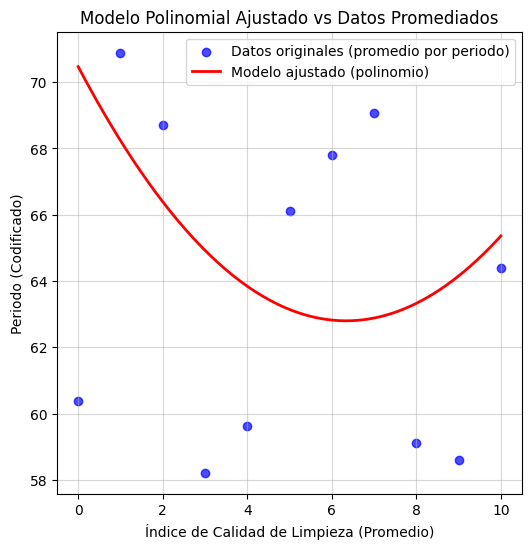

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Generar predicciones para un rango suave de valores de índice de limpieza
x_range = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
y_pred_smooth = model.predict(x_range)

# Graficar datos originales promediados
plt.figure(figsize=(6, 6))
plt.scatter(
    X, y, color="blue", alpha=0.7, label="Datos originales (promedio por periodo)"
)

# Graficar el modelo ajustado
plt.plot(x_range, y_pred_smooth, color="red", linewidth=2, label="Modelo ajustado (polinomio)")

# Etiquetas y detalles
plt.title("Modelo Polinomial Ajustado vs Datos Promediados")
plt.xlabel("Índice de Calidad de Limpieza (Promedio)")
plt.ylabel("Periodo (Codificado)")
plt.legend()
plt.grid(alpha=0.5)
plt.show()


Me fijo si puedo predecir el criterio sabiendo porcentaje de cumplimiento y estratificacion geografica:

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
# Defino X (features) e y (targets)

X = df[['Porcentaje_de_cumplimiento', "Estratificacion_geografica"]].dropna()
y = df['Criterio'].dropna().astype(str)  # Target


# Codificación para X
encoder = ColumnTransformer(
    [("geo_enc", OrdinalEncoder(), ["Estratificacion_geografica"]),
],
    remainder="passthrough"
)


 # Codificación para variables categóricas
X = encoder.fit_transform(X)

# Pipeline con codificación y estandarización
pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LogisticRegression())  # Modelo de regresión logística
    ]
)

# Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ajustar el modelo
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
baseline_accuracy = y_test.value_counts(normalize=True).max()
print(f"Baseline Accuracy: {baseline_accuracy:.2f}")
# Evaluación del modelo
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Baseline Accuracy: 0.27
Model Accuracy: 0.60
Confusion Matrix:
[[13  0  0  0  0]
 [ 2  5  0  6  0]
 [ 0  0 17  3  0]
 [ 0  0  3 10  0]
 [14  3  0  1  4]]

Classification Report:
                              precision    recall  f1-score   support

     Disposicion_de_residuos       0.45      1.00      0.62        13
  Grafitis_pegatinas_y_otros       0.62      0.38      0.48        13
               Heces_caninas       0.85      0.85      0.85        20
Limpieza_de_veredas_y_calles       0.50      0.77      0.61        13
Mobiliario_de_higiene_urbana       1.00      0.18      0.31        22

                    accuracy                           0.60        81
                   macro avg       0.68      0.64      0.57        81
                weighted avg       0.73      0.60      0.57        81



In [ ]:
from sklearn.model_selection import cross_val_score
#Pruebo con distintos pliegues si los resultados son similares
scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
print(f"Cross-validated accuracy: {scores.mean():.2f} ± {scores.std():.2f}")

Cross-validated accuracy: 0.56 ± 0.07


Pruebo distintos hiperparametros:

In [ ]:
from sklearn.model_selection import GridSearchCV
# Parámetros para ajustar
param_grid = {
    "model__penalty": ["l1", "l2"],  # Tipos de regularización
    "model__solver": ["liblinear", "saga"],  # Algoritmos compatibles
    "model__C": [0.1, 1, 10],  # Regularización
    "model__max_iter": [100, 200],  # Iteraciones máximas
}

# Ajuste de hiperparámetros
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,  # Validación cruzada
    scoring="accuracy",
    verbose=2,
    n_jobs=-1,
    error_score="raise",  # Detener en errores
)

# Entrenamiento
grid_search.fit(X_train, y_train)

# Resultados
print("Mejores parámetros:", grid_search.best_params_)
print("Mejor accuracy en validación cruzada:", grid_search.best_score_)

# Evaluación en el conjunto de prueba
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Accuracy en prueba:", accuracy_score(y_test, y_pred))


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores parámetros: {'model__C': 0.1, 'model__max_iter': 100, 'model__penalty': 'l1', 'model__solver': 'saga'}
Mejor accuracy en validación cruzada: 0.5707692307692308
Accuracy en prueba: 0.5555555555555556


Predice el criterio con una precision (accuracy) del 57%.

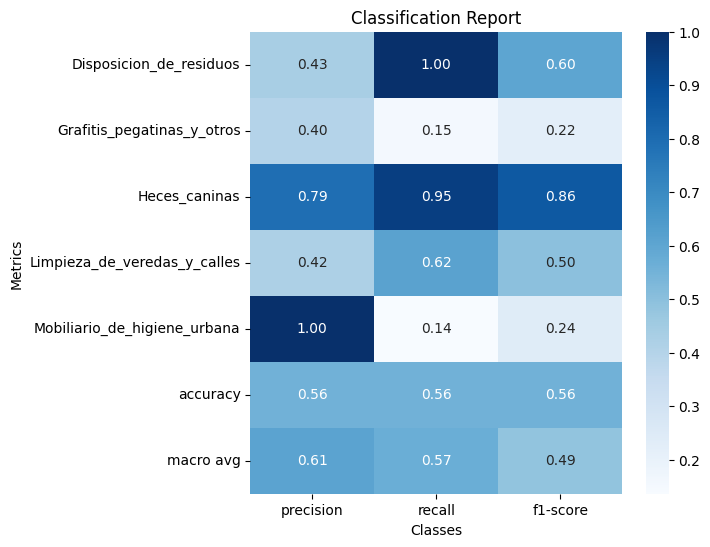

In [ ]:
#Grafico el classification report
report=classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
plt.figure(figsize=(6, 6))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap="Blues", fmt=".2f")
plt.title("Classification Report")
plt.ylabel("Metrics")
plt.xlabel("Classes")
plt.show()

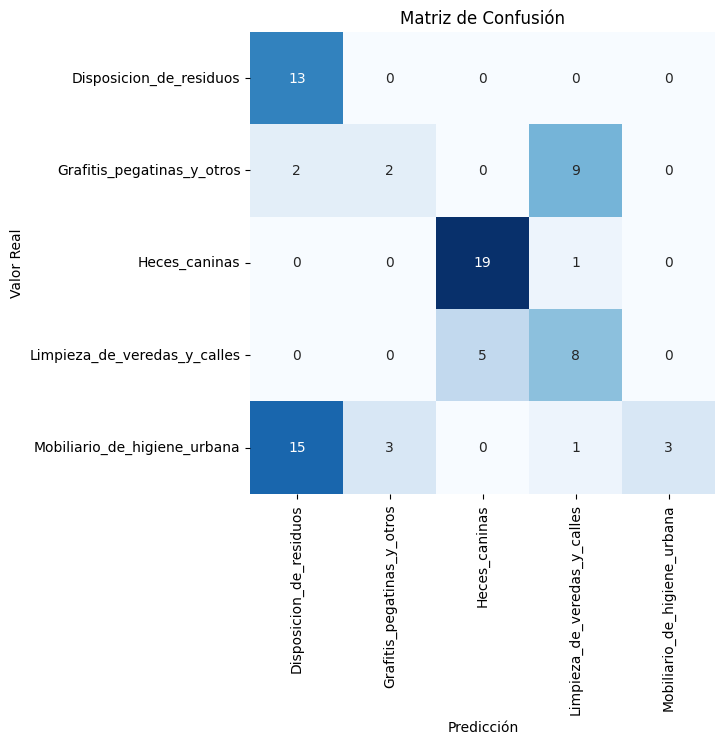

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Obténgo la matriz de confusión y luego la grafico
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()

 Por la matriz de confusion veo que le cuesta predecir con precision el "mobiliario de higiene urbano", siendo confundido con "disposicion de residuos", y "grafitis,pegatinas y otros", confundido con "limpieza de veredas". Estos resultados eran de predecir cuando graficamos los clusters.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer

#Veo cual es la variable mas importante para predecir el criterio
model = RandomForestClassifier()
model.fit(X, y)
print(model.feature_importances_)
print(encoder.get_feature_names_out())

[0.13986058 0.86013942]
['geo_enc__Estratificacion_geografica'
 'remainder__Porcentaje_de_cumplimiento']


La varible mas importante para predecir el criterio es el porcentaje de cumplimiento.

Se ve claramente la diferencia entre el polinomio y los valores originales, por lo que la relacion entre el periodo y el indice de calidad de limpieza es despreciable. Esto tambien se puede deber a la escasa de datos para entrenar el modelo.